In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
N = 100

folder_path = r"S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026/Actual_Data"

joint_files = {
    1: "J_1_12.06.2026_13_05_36.csv",
    2: "J_2_12.06.2026_13_22_35.csv",
    3: "J_3_12.06.2026_13_13_15.csv",
    5: "J_5_12.06.2026_13_14_50.csv"
}


JOINT 1


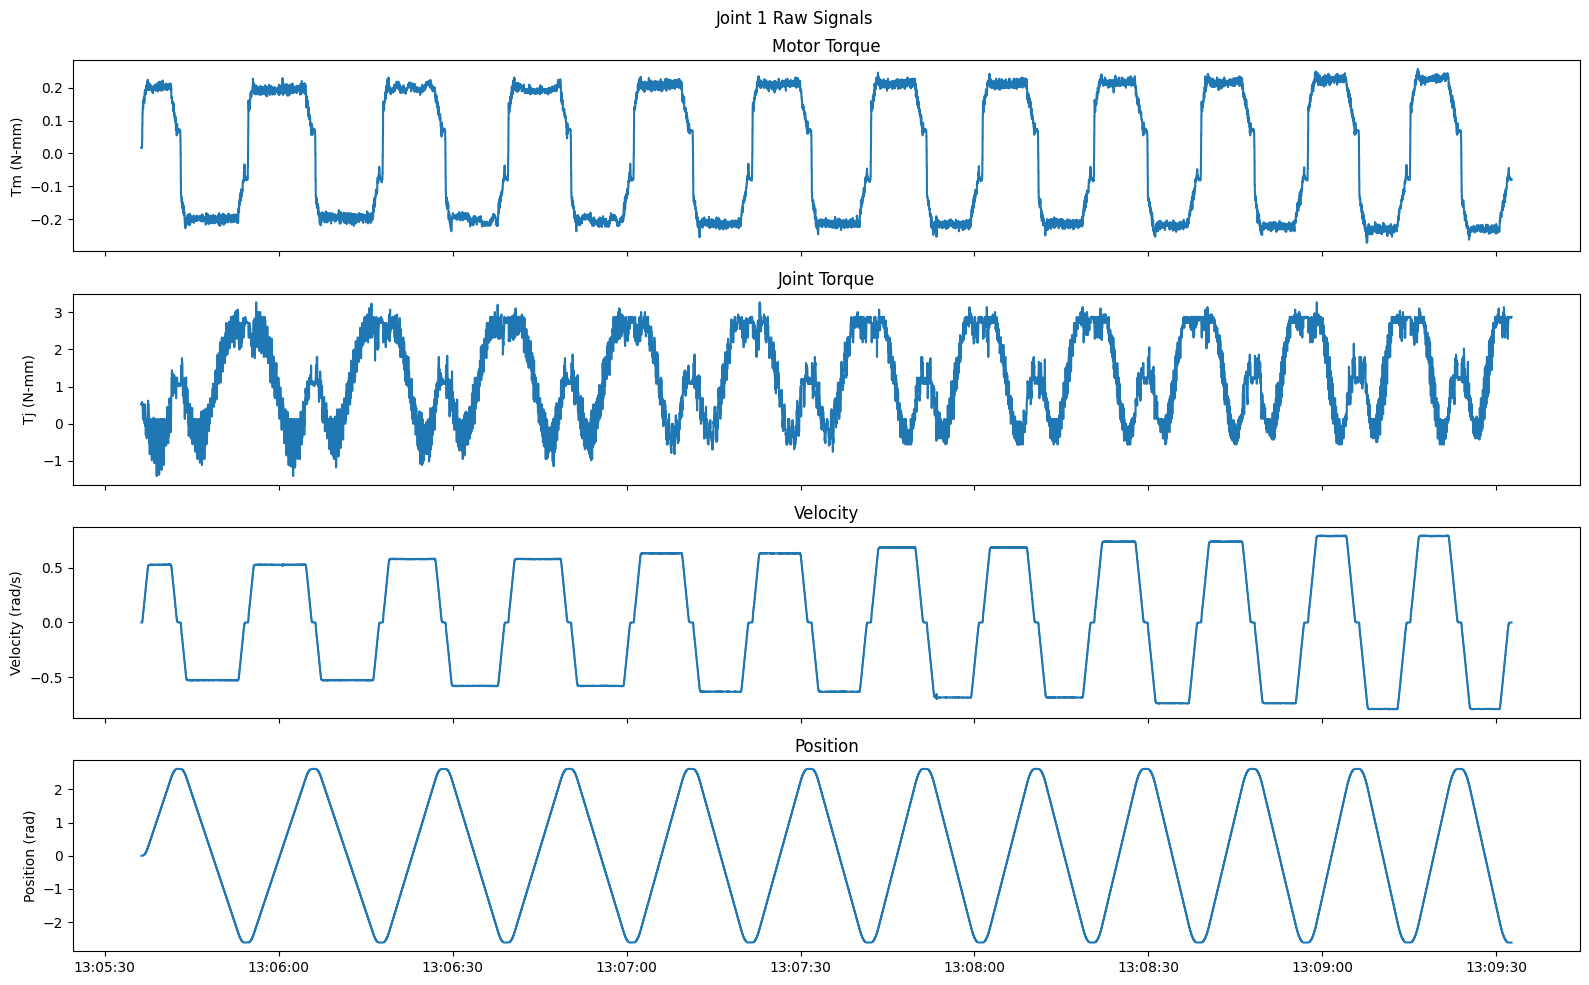

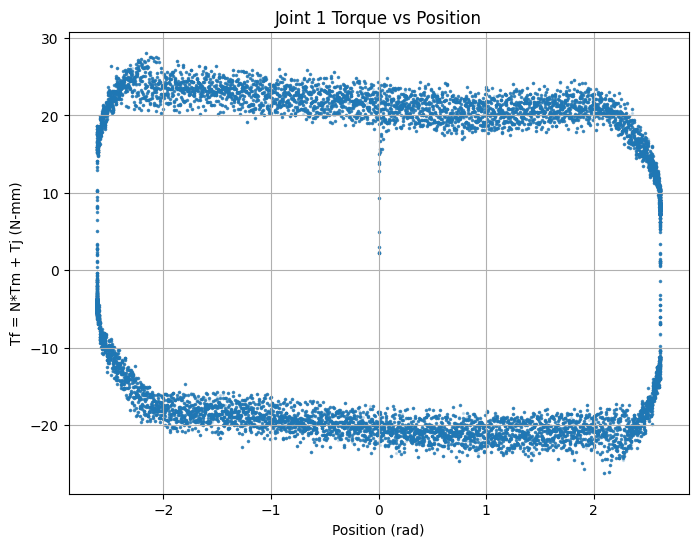

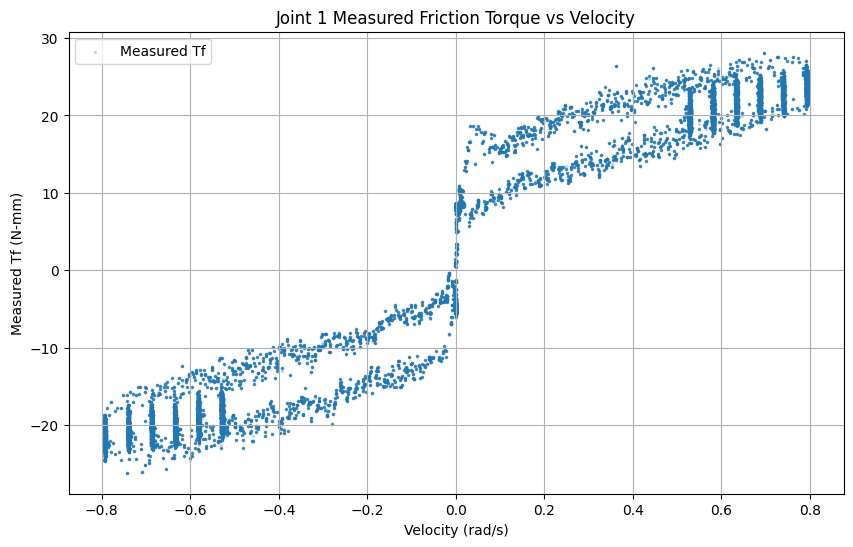


JOINT 2


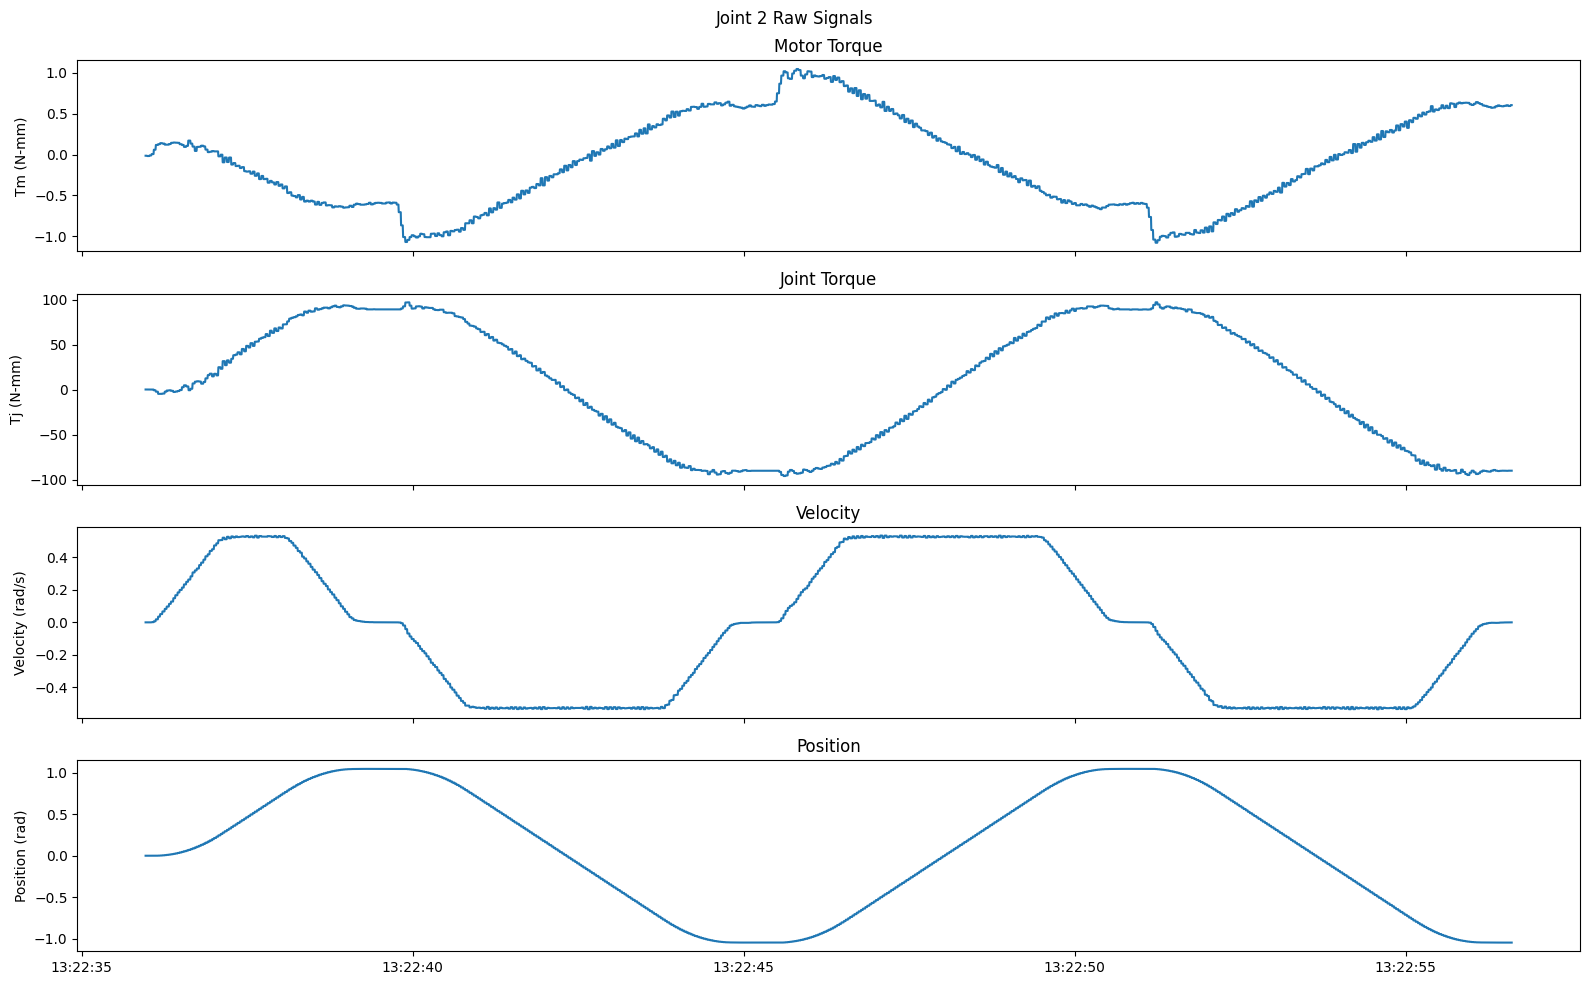

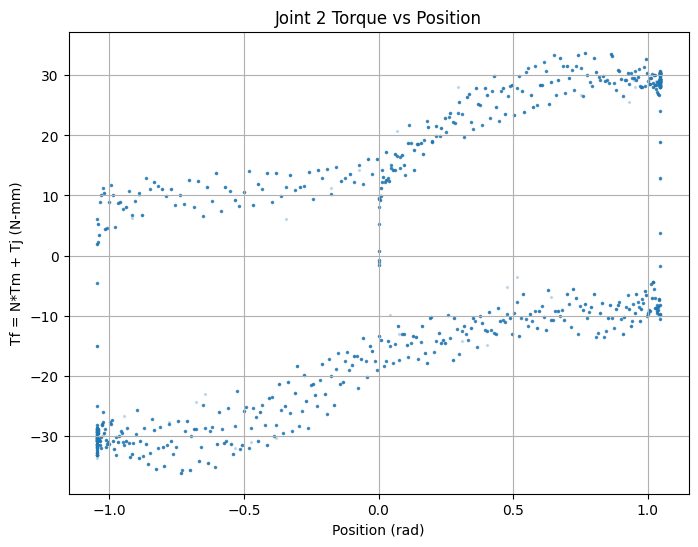

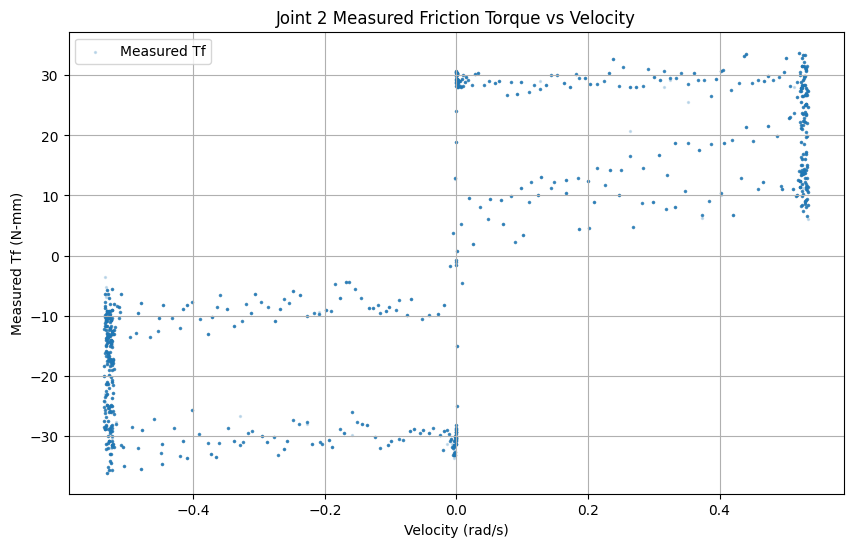


JOINT 3


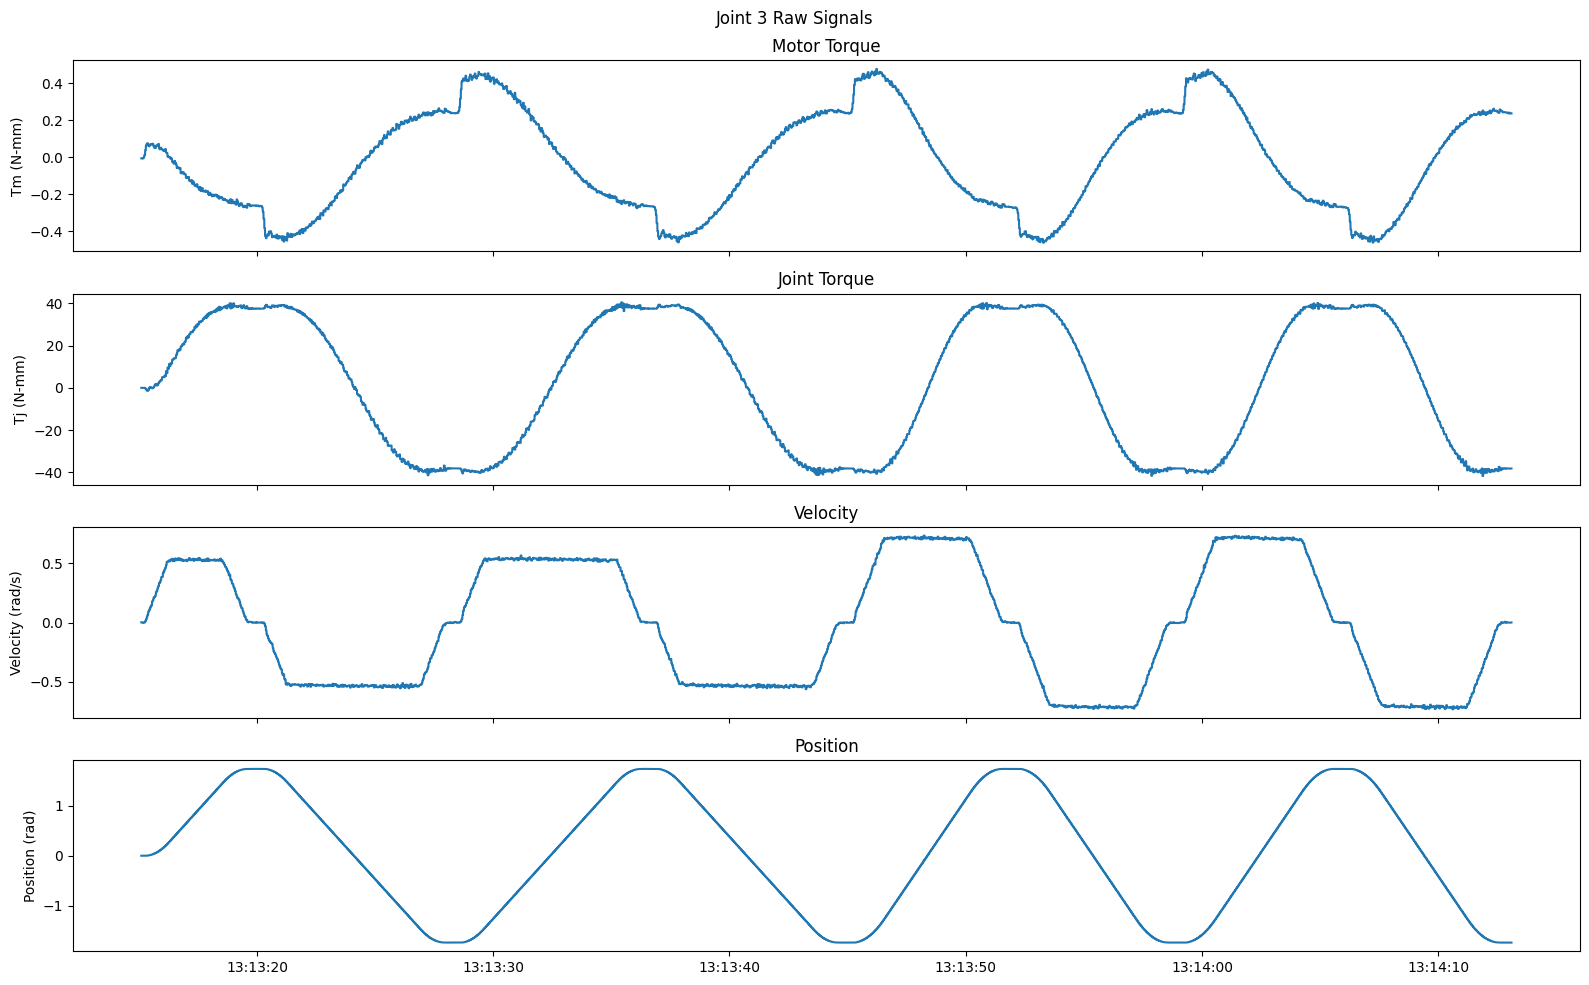

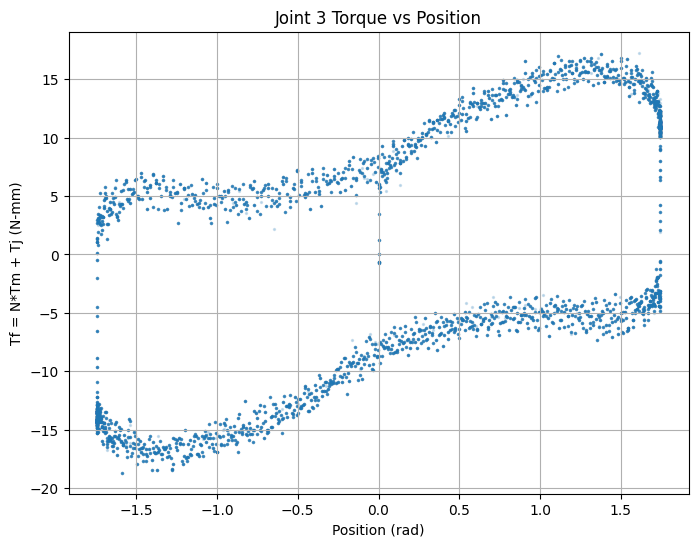

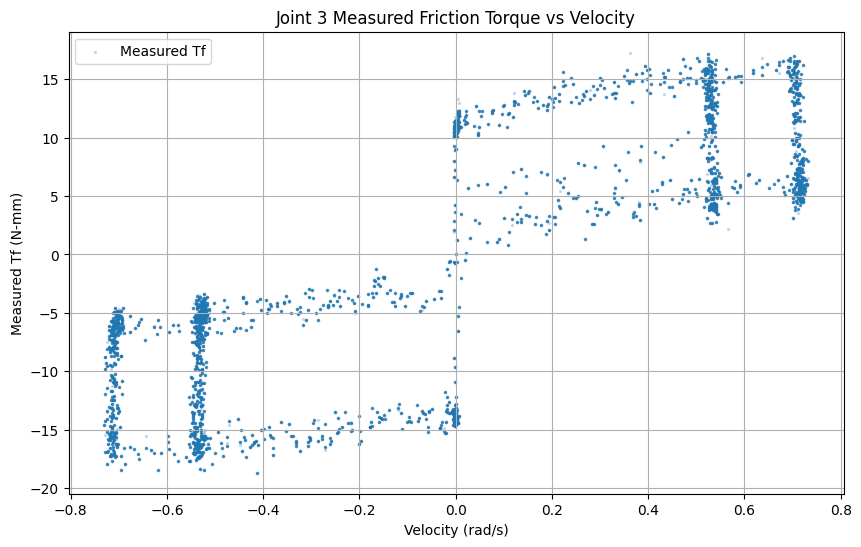


JOINT 5


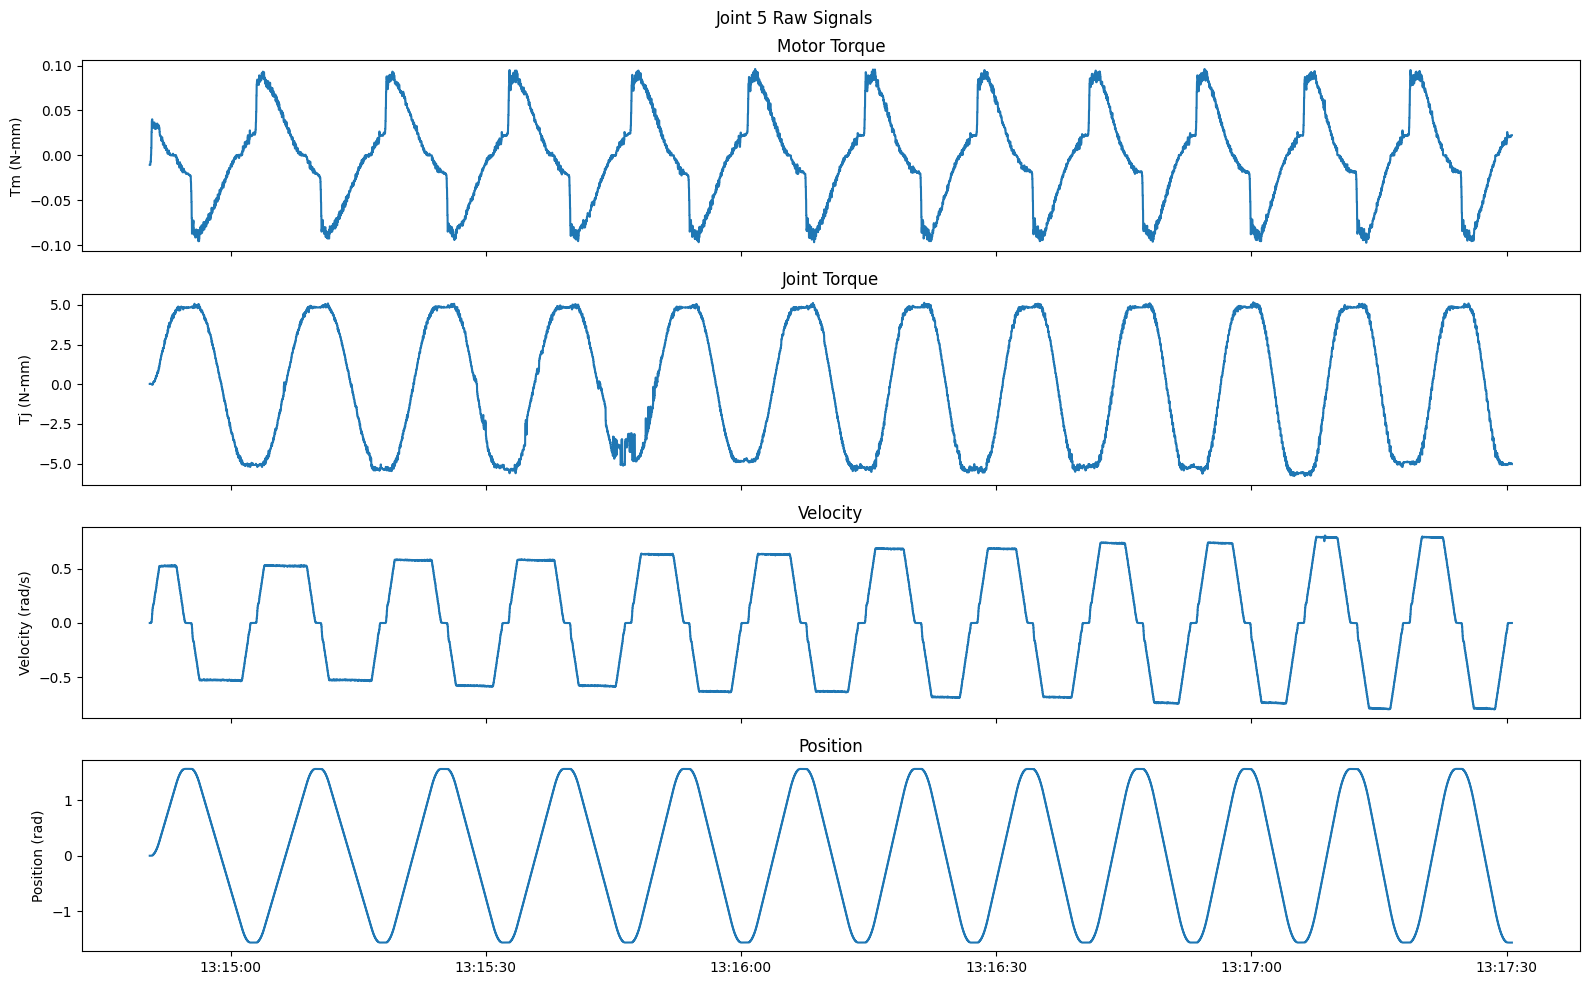

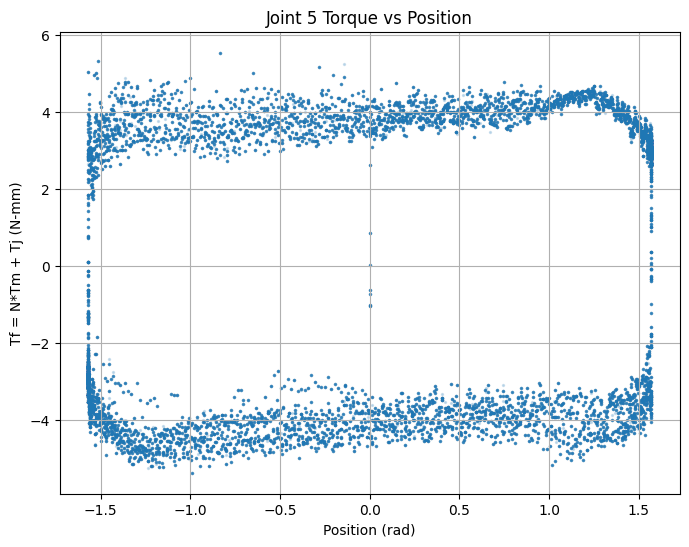

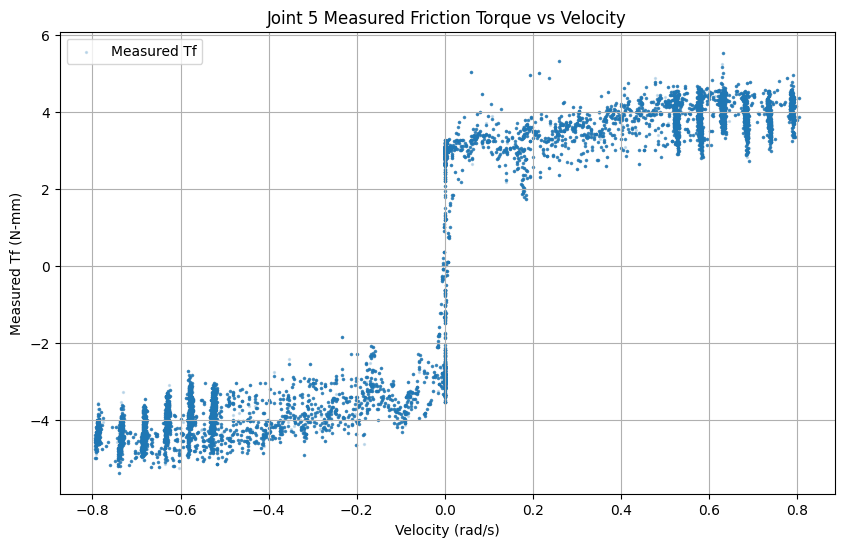

In [4]:
for joint, filename in joint_files.items():
    print("\n" + "=" * 70)
    print(f"JOINT {joint}")
    print("=" * 70)
    
    file_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    # ==========================================
    # TIMESTAMP
    # ==========================================
    df["timestamp"] = pd.to_datetime("2026-06-12 " + df["timestamp"].astype(str))

    # ==========================================
    # COMMON COLUMNS
    # ==========================================
    df["q"] = np.deg2rad(df[f"q{joint}"])
    df["v"] = np.deg2rad(df[f"v{joint}"])
    df["tm"] = df[f"m_t_{joint}"]
    df["tj"] = df[f"jts{joint}"]
    
    # Equation: Tf = N*Tm - (-Tj) -> N*Tm + Tj
    df["tf"] = (N * df["tm"] - (-df["tj"]))

    # ==========================================
    # RAW SIGNALS VS TIME
    # ==========================================
    fig, ax = plt.subplots(4, 1, figsize=(16,10), sharex=True)
    
    ax[0].plot(df["timestamp"], df["tm"])
    ax[0].set_title("Motor Torque")
    ax[0].set_ylabel("Tm (N-mm)") 
    
    ax[1].plot(df["timestamp"], df["tj"])
    ax[1].set_title("Joint Torque")
    ax[1].set_ylabel("Tj (N-mm)") 
    
    ax[2].plot(df["timestamp"], df["v"])
    ax[2].set_title("Velocity")
    ax[2].set_ylabel("Velocity (rad/s)")
    
    ax[3].plot(df["timestamp"], df["q"])
    ax[3].set_title("Position")
    ax[3].set_ylabel("Position (rad)")
    
    plt.suptitle(f"Joint {joint} Raw Signals")
    plt.tight_layout()
    plt.show()

    # ==========================================
    # TORQUE VS POSITION
    # ==========================================
    plt.figure(figsize=(8,6))
    plt.scatter(df["q"], df["tf"], s=2, alpha=0.2)
    plt.xlabel("Position (rad)")
    plt.ylabel("Tf = N*Tm + Tj (N-mm)") 
    plt.title(f"Joint {joint} Torque vs Position")
    plt.grid(True)
    plt.show()

    # ==========================================
    # FRICTION TORQUE VS VELOCITY (MEASURED ONLY)
    # ==========================================
    plt.figure(figsize=(10,6))
    plt.scatter(df["v"], df["tf"], s=2, alpha=0.2, label="Measured Tf")
    plt.xlabel("Velocity (rad/s)")
    plt.ylabel("Measured Tf (N-mm)") 
    plt.title(f"Joint {joint} Measured Friction Torque vs Velocity")
    plt.legend()
    plt.grid(True)
    plt.show()

# PLOT FOR UNIQUE DATASET WITH ACCELERATION